# Data Understanding

In [3]:
import pandas as pd

# import data
spotify_data = pd.read_csv('spotify_songs.csv')
spotify_data.head()

,track_id,track_name,track_artist,lyrics,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,language
0,0017A6SJgTbfQVU2EtsPNo,Pangarap,Barbie's Cradle,Minsan pa Nang ako'y napalingon Hindi ko alam ...,41,1srJQ0njEQgd8w4XSqI4JQ,Trip,2001-01-01,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,...,-10.068,1,0.0236,0.27900,0.01170,0.0887,0.566,97.091,235440,tl
1,004s3t0ONYlzxII9PLgU6z,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,3z04Lb9Dsilqw68SHt6jLB,Love & Loss,2017-11-21,Hard Rock Workout,3YouF0u7waJnolytf9JCXf,...,-4.739,1,0.0442,0.01170,0.00994,0.3470,0.404,135.225,373512,en
2,00chLpzhgVjxs1zKC9UScL,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",0,6oZ6brjB8x3GoeSYdwJdPc,Gold,2005-01-01,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,...,-7.504,0,0.2160,0.00432,0.00723,0.4890,0.650,111.904,262467,en
3,00cqd6ZsSkLZqGMlQCR0Zo,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,41,3ssspRe42CXkhPxdc12xcp,CeeLo's Magic Moment,2012-10-29,Christmas Soul,6FZYc2BvF7tColxO8PBShV,...,-5.819,0,0.0341,0.68900,0.00000,0.0664,0.405,118.593,243067,en
4,00emjlCv9azBN0fzuuyLqy,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,65,7h5X3xhh3peIK9Y0qI5hbK,KARD 2nd Digital Single ‘Dumb Litty’,2019-09-22,K-Party Dance Mix,37i9dQZF1DX4RDXswvP6Mj,...,-1.993,1,0.0409,0.03700,0.00000,0.1380,0.240,130.018,193160,en


(18454, 25)


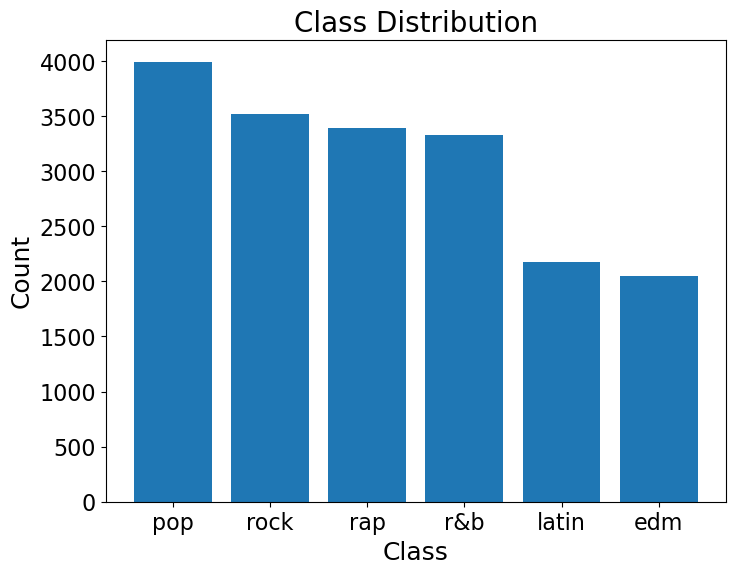

In [4]:
# Data Exploration
print(spotify_data.shape)

import matplotlib.pyplot as plt

class_counts = spotify_data['playlist_genre'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Class', fontsize=18)
plt.ylabel('Count', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('Class Distribution', fontsize=20)
plt.show()

# plt.figure(figsize=(8, 8))
# plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=0, textprops={'fontsize': 14})
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
# plt.title('Class Distribution', fontsize=16)
# plt.show()

In [21]:
# Statistics of the numerical features
stats = spotify_data.describe()
temp = stats.drop(columns=['key', 'mode']).round(decimals=4).transpose()
print(temp)

                    count         mean         std         min          25%  \
track_popularity  18454.0      42.4388     24.6167      0.0000      24.0000   
danceability      18454.0       0.6441      0.1501      0.0985       0.5460   
energy            18454.0       0.6923      0.1806      0.0167       0.5730   
loudness          18454.0      -6.7692      2.9208    -34.2830      -8.2490   
speechiness       18454.0       0.1062      0.1023      0.0224       0.0397   
acousticness      18454.0       0.1753      0.2178      0.0000       0.0161   
instrumentalness  18454.0       0.0512      0.1683      0.0000       0.0000   
liveness          18454.0       0.1896      0.1538      0.0094       0.0927   
valence           18454.0       0.5206      0.2287      0.0000       0.3450   
tempo             18454.0     120.8122     27.5864     37.1140      98.8560   
duration_ms       18454.0  230319.3068  57255.0867  31893.0000  193230.2500   

                          50%          75%         

In [14]:
from sklearn.feature_selection import r_regression
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encoding target variable to interger values
encoder = LabelEncoder()
encoder.fit(['latin', 'r&b' ,'rap' ,'rock', 'edm', 'pop'])
cols = list(stats.columns.array)
spotify_data_slim = spotify_data[list(stats.columns.array)].copy()
spotify_data_target = encoder.transform(spotify_data['playlist_genre'])

# Normalize unnormalized data
scaler = StandardScaler()
spotify_data_slim = pd.DataFrame(scaler.fit_transform(spotify_data_slim), columns=spotify_data_slim.columns)
spotify_data_slim.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,-0.058450,0.252779,-1.612626,-0.925013,-1.129478,0.850047,-0.807439,0.475927,-0.234851,-0.656229,0.198512,-0.859909,0.089439
1,-0.586561,-2.272760,1.039196,1.012423,0.695098,0.850047,-0.606048,-0.751409,-0.245311,1.023809,-0.509808,0.522475,2.501028
2,-1.724029,1.338961,-0.223049,0.182093,-0.251600,-1.176405,1.073519,-0.785295,-0.261417,1.947406,0.565789,-0.322927,0.561497
3,-0.058450,-1.459790,-1.739958,-0.094684,0.325321,-1.176405,-0.704788,2.358484,-0.304386,-0.801273,-0.505436,-0.080446,0.222653
4,0.916522,0.772547,1.077949,1.012423,1.635291,0.850047,-0.638310,-0.635241,-0.304386,-0.335571,-1.226873,0.333718,-0.649031


In [7]:
from sklearn.linear_model import LogisticRegression

# Assuming X_train, X_test are your feature matrices and y_train is your target vector
# X_train, X_test, y_train = ...

# Instantiate and fit the model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(spotify_data_slim, spotify_data_target)

# Get regression coefficients
coefficients = model.coef_

coef_df = pd.DataFrame(coefficients, columns=spotify_data_slim.columns)
coef_df.index = encoder.classes_

# Print coefficients
print("Regression Coefficients:")
display(coef_df)

Regression Coefficients:


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
edm,-0.299575,0.402203,0.438161,-0.003821,0.596320,-0.131790,-0.094221,-0.241843,0.398072,0.052793,-0.716137,0.219182,-0.183403
latin,0.061446,0.418502,-0.009161,0.026253,0.132929,0.012362,0.085408,0.301466,-0.153232,0.037611,0.274117,-0.037235,-0.069763
pop,0.238461,-0.154383,-0.082730,-0.009034,0.090578,0.051320,-0.355743,-0.021562,0.127381,-0.074686,-0.004824,0.001457,-0.186716
r&b,-0.155935,0.005699,-0.756412,-0.002939,-0.059171,-0.091602,0.351396,0.100527,-0.292099,-0.026097,0.249683,-0.152898,0.285252
rap,-0.037032,0.702781,-0.247634,0.007843,0.098808,-0.050041,0.934946,-0.065265,-0.016010,0.073409,-0.309081,0.079667,-0.033093
rock,0.192635,-1.374801,0.657776,-0.018301,-0.859465,0.209751,-0.921786,-0.073323,-0.064113,-0.063030,0.506240,-0.110173,0.187724


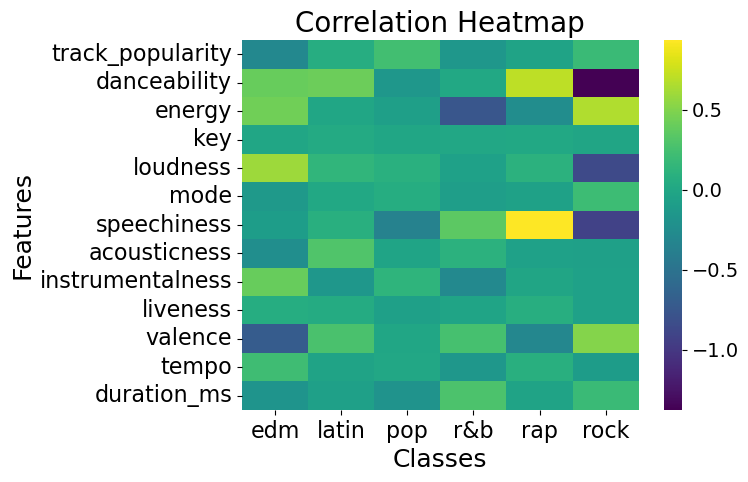

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create heatmap
heatmap = sns.heatmap(coef_df.T, cmap='viridis')

# Add labels
plt.ylabel('Features', fontsize=18)
plt.xlabel('Classes', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('Correlation Heatmap', fontsize=20)

# Increase the fontsize of colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Adjust fontsize of colorbar labels

# Show plot
plt.show()

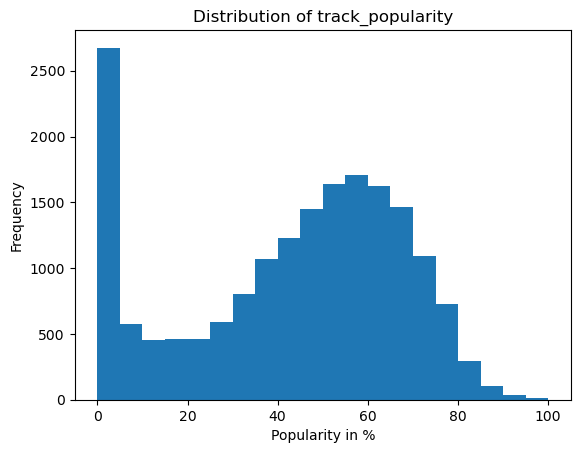

(1647, 25)


In [22]:
# draw a histogram of track_popularity
plt.title('Distribution of track_popularity')
plt.hist(spotify_data['track_popularity'], bins=20)
plt.xlabel('Popularity in %')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data['track_popularity'] == 0].shape)

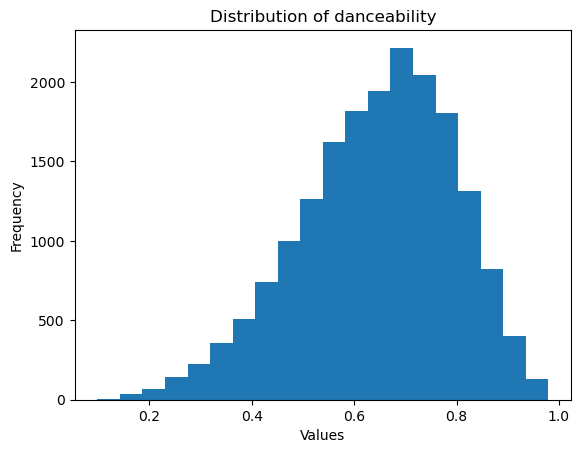

(0, 25)


In [23]:
# draw a histogram of danceability
col = 'danceability'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=20)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0.0].shape)

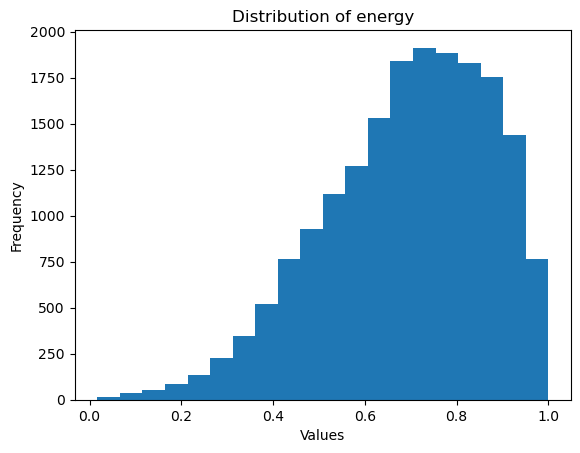

(0, 25)


In [24]:
# draw a histogram of energy
col = 'energy'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=20)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0.0].shape)

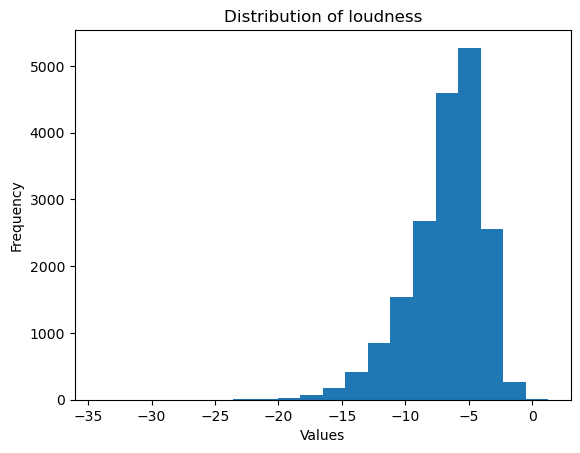

(0, 25)


In [25]:
# draw a histogram of loudness
col = 'loudness'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=20)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0.0].shape)

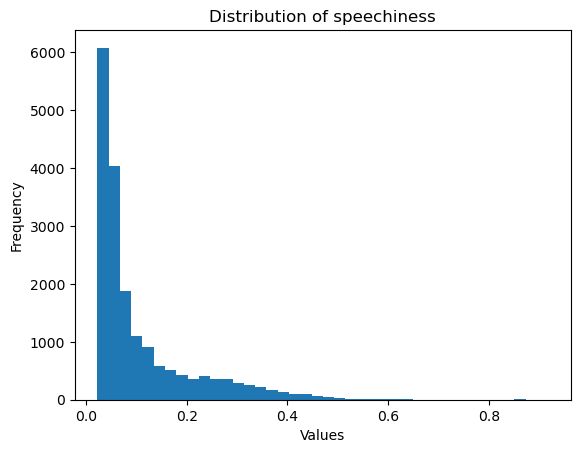

(0, 25)


In [26]:
# draw a histogram of speechiness
col = 'speechiness'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=40)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0.0].shape)

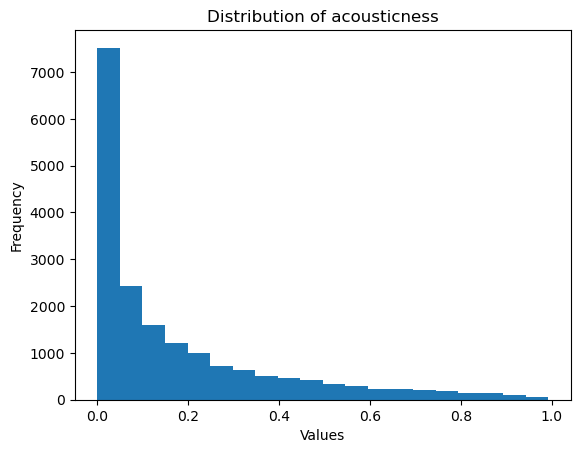

(0, 25)


In [27]:
# draw a histogram of acousticness
col = 'acousticness'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=20)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0.0].shape)

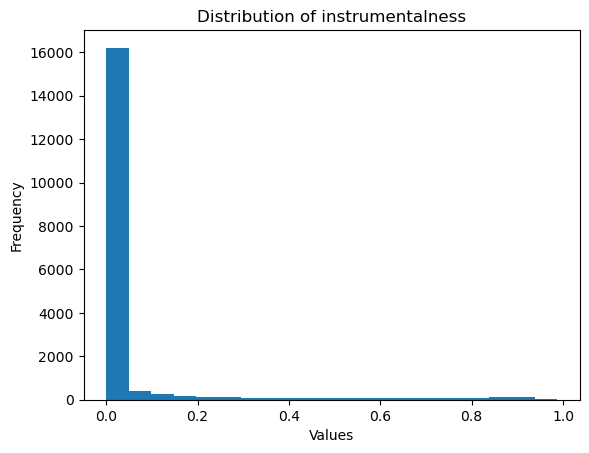

(7213, 25)


In [29]:
# draw a histogram of instrumentalness
col = 'instrumentalness'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=20)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0.0].shape)

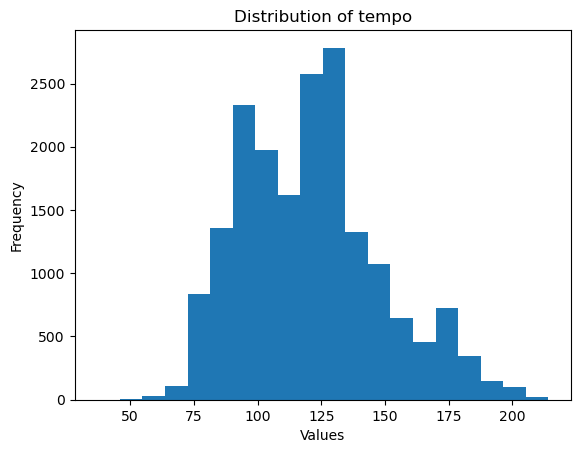

(0, 25)


In [30]:
# draw a histogram of tempo
col = 'tempo'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=20)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0].shape)

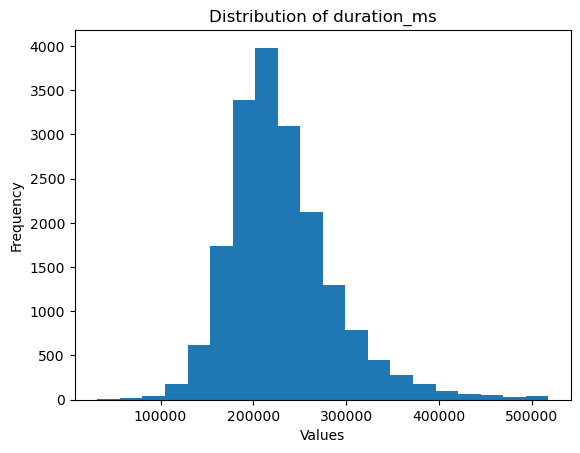

(0, 25)


In [31]:
# draw a histogram of duration_ms
col = 'duration_ms'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=20)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0].shape)

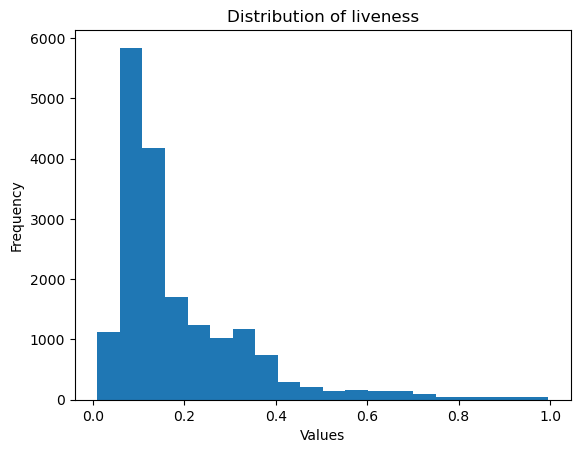

(0, 25)


In [32]:
# draw a histogram of liveness
col = 'liveness'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=20)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0].shape)

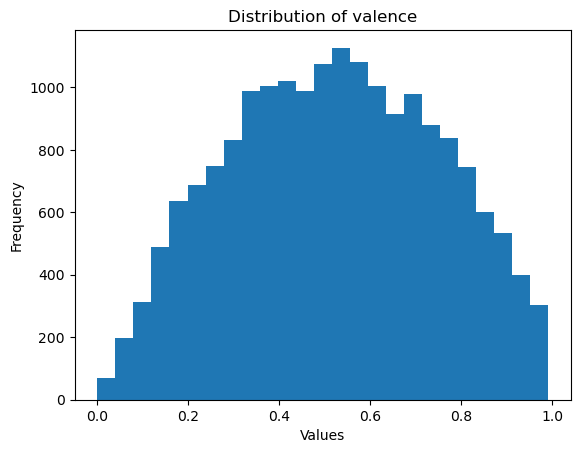

(0, 25)


In [33]:
# draw a histogram of valence
col = 'valence'
plt.title('Distribution of {}'.format(col))
plt.hist(spotify_data[col], bins=25)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

print(spotify_data[spotify_data[col] == 0.0].shape)

# Preprocessing

In [2]:
# Data Understanding and Preprocessing were separate processes.
# The same importing process may be repeated while merging 2 separate ipynb files.

# imports
import pandas as pd

### Cleaning and Pruning Data

In [3]:
# importing dataset
spotify_data = pd.read_csv('spotify_songs.csv')
# selecting only english songs
spotify_data = spotify_data[ spotify_data['language'] == 'en']
# removing irrelevant columns
spotify_data_simplified = spotify_data.drop(columns=['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_subgenre', 'language'])
spotify_data_simplified.reset_index(drop=True, inplace=True)

# Change the name of the feature -> prevent duplication with word tokens
# that will be created later through text mining

first_last_columns = ['lyrics', 'playlist_genre']
new_columns = [col + '_F' if col not in first_last_columns else col for col in spotify_data_simplified.columns]
spotify_data_simplified.columns = new_columns
spotify_data_simplified.columns

Index(['lyrics', 'track_popularity_F', 'playlist_genre', 'danceability_F',
       'energy_F', 'key_F', 'loudness_F', 'mode_F', 'speechiness_F',
       'acousticness_F', 'instrumentalness_F', 'liveness_F', 'valence_F',
       'tempo_F', 'duration_ms_F'],
      dtype='object')

In [4]:
# encode labels

label = {}
for index, genre in enumerate(spotify_data_simplified.playlist_genre.unique()):
  label[genre] = index

label_dictionary = label

# Check what number each genre is assigned to

label

{'rock': 0, 'r&b': 1, 'pop': 2, 'edm': 3, 'rap': 4, 'latin': 5}

In [5]:
# Apply to original data

spotify_data_simplified.playlist_genre.replace(label,inplace=True)

In [6]:
# normalising numerical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
  transformers=[
    ('normalize', StandardScaler(), ['track_popularity_F', 'loudness_F', 'tempo_F', 'duration_ms_F'])
  ],
  remainder='passthrough'
)

spotify_data_simplified = pd.DataFrame(preprocessor.fit_transform(spotify_data_simplified), columns=preprocessor.get_feature_names_out())

In [42]:
# simplifying column names
prefix = ['normalize__', 'remainder__']
new_columns = []
for col in spotify_data_simplified.columns:
  if col.startswith(prefix[0]):
    new_columns.append(col.removeprefix(prefix[0]))
  elif col.startswith(prefix[1]):
    new_columns.append(col.removeprefix(prefix[1]))
  else:
    new_columns.append(col)

spotify_data_simplified.columns = new_columns

### Extracting Features

In [7]:
# Preparing for text cleaning
# Tokenize, Remove stopwords, Stemming, Remove unnecessary words, convert special characters...
# We tested both Stemming and Lemmatization and confirmed that stemming was more suitable.

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import re
from nltk import pos_tag
stop_words = set(stopwords.words("english"))
month_list = ['january', 'jan', 'february', 'feb', 'march', 'mar', 'april', 'apr',
              'may', 'may', 'june', 'jun', 'july', 'jul', 'august', 'aug',
              'september', 'sep', 'october', 'oct', 'november', 'nov', 'december', 'dec']

weekday_list = ['monday', 'mon', 'tuesday', 'tue', 'wednesday', 'wed', 'thursday', 'thu',
                'friday', 'fri', 'saturday', 'sat', 'sunday', 'sun', 'today', ' tomorrow', 'yesterday', 'week']

numbers = ['two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']

stemmer = PorterStemmer()

def preprocess_whole_document_text_optimized(text):
    text = re.sub(r"\s+", " ", text)
    text = text.lower()
    text = text.replace("\\n", "")
    text = re.sub("[^a-zA-Z]", " ", text)

    tokens = word_tokenize(text)

    pos_tags = pos_tag(tokens)
    words = [
        stemmer.stem(word)
        for word, pos_tag in pos_tags
        if (
                word.isalpha()
                and word not in stop_words and stemmer.stem(word) not in stop_words
                and word not in month_list and stemmer.stem(word) not in month_list
                and word not in weekday_list and stemmer.stem(word) not in weekday_list
                and word not in numbers and stemmer.stem(word) not in numbers
                and len(word) > 2
        )
    ]

    preprocessed_text = " ".join(words)
    if len(preprocessed_text) < 100:
        return None

    return preprocessed_text

In [44]:
# Apply to Lyrics column
spotify_data_simplified['lyrics'] = spotify_data_simplified['lyrics'].apply(preprocess_whole_document_text_optimized)

In [45]:
# Copy refined data to a new data frame to prevent corruption

spotify = spotify_data_simplified.copy()

# count how many missing values present
spotify.isna().sum() # 154

spotify.dropna(subset=['lyrics'], inplace=True)

# reset index
spotify.reset_index(drop=True, inplace=True)

In [46]:
# Calculate TF-IDF value through TfidfVectorizer,
# limit the number of generated features to 4000 or 10000? / and consider only single words? or not?
# Save vectorizer as 'PreprocessingVectorizer.sav'

from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

mono_vectorizer = TfidfVectorizer(use_idf=True, max_features = 4000, ngram_range=(1,1))
matrix = mono_vectorizer.fit_transform(spotify['lyrics'])

features = pd.DataFrame(matrix.toarray(), columns=mono_vectorizer.get_feature_names_out())
features.index = spotify.index

filename = f'PreprocessingMonoVectorizer.sav'
joblib.dump(mono_vectorizer, filename)

# We also applied ngram_range=(1,2) but found that some important words were duplicated.

['PreprocessingMonoVectorizer.sav']

In [48]:
# save dataset
spotify_features = pd.concat([spotify, features], axis=1)
spotify_features.to_csv('spotify_4000_monograms.csv')

In [49]:
# dual grams
dual_vectorizer = TfidfVectorizer(use_idf=True, max_features = 10000, ngram_range=(1,2))
matrix = dual_vectorizer.fit_transform(spotify['lyrics'])

features = pd.DataFrame(matrix.toarray(), columns=dual_vectorizer.get_feature_names_out())
features.index = spotify.index

filename = f'PreprocessingDualVectorizer.sav'
joblib.dump(dual_vectorizer, filename)

# We increased the number of features to 10000 so that we can make
# the parameter ngram_range=(1,2) work better

['PreprocessingDualVectorizer.sav']

In [50]:
# save dual grams dataset 
spotify_features = pd.concat([spotify, features], axis=1)
spotify_features.to_csv('spotify_10000_dualgrams.csv')

Before we made these 2 final datasets "spotify_4000_monograms.csv" and "spotify_10000_dualgrams.csv", we also tried correlation based feature selection and made several datasets which contain different number of features selected by different thresholds, but due to the time limit we could not train models with the datasets.

From now on, these are the codes that were used during the process.
(This process also contains train/test split step)

In [52]:
# Create a dataset excluding Lyrics

spotify_features_cor = spotify_features.drop(columns=['lyrics'])

In [ ]:
# Specify features and target to create correlation matrix

features = spotify_features_cor.drop(columns=['playlist_genre'])
target = spotify_features_cor['playlist_genre']

In [ ]:
# Create correlation matrix

correlation_matrix = features.corrwith(target)

In [ ]:
# Visualize top n variables with the highest correlation value and their correlation value

import matplotlib.pyplot as plt

def select_and_plot_features(num_features):
    selected_features = correlation_matrix.abs().nlargest(num_features).index
    correlation_values = correlation_matrix[selected_features].abs().nlargest(num_features)
    plt.figure(figsize=(15, 10))
    plt.bar(selected_features, correlation_values)
    plt.xticks(rotation=90)
    plt.xlabel('Selected Features')
    plt.ylabel('Absolute Correlation Coefficient')
    plt.title(f'Top {num_features} Features')
    plt.show()
    
    for feature, value in correlation_values.items():
        print(f"{feature}: {value}")
    
    plt.show()

for n in [10, 20, 30, 50, 70]:
    select_and_plot_features(n)

In [ ]:
# Split and save train and test sets : select top n features for each cases
# monogram(max 4000), dualgram(max 10000)

from sklearn.model_selection import train_test_split

for n in [10, 20, 30, 50, 70]:
    
    top_n_features = correlation_matrix.abs().nlargest(n).index
    new_df = spotify_features_cor[list(top_n_features) + ['playlist_genre']]
    
    X_train, X_test, y_train, y_test = train_test_split(new_df.iloc[:,:-1], new_df["playlist_genre"], test_size=0.30, random_state=42)
    
    train_df = pd.concat([X_train, y_train], axis=1)
    train_df.to_csv(f'Spotify_top_{n}_train_10000.csv')
    
    test_df = pd.concat([X_test, y_test], axis=1)
    test_df.to_csv(f'Spotify_top_{n}_test_10000.csv')

In [ ]:
# Split and save train and test sets : select features whose correlation value exceeds 0.15/0.1/0.05

for n in [0.15, 0.1, 0.05]:
    
    above_n_features = correlation_matrix[correlation_matrix.abs() > n].index
    new_df = spotify_features_cor[list(above_n_features) + ['playlist_genre']]
    
    X_train, X_test, y_train, y_test = train_test_split(new_df.iloc[:,:-1], new_df["playlist_genre"], test_size=0.30, random_state=42)
    
    num_selected_features = len(above_n_features)
    print(f"Number of selected features for correlation value > {n}: {num_selected_features}")
    
    train_df = pd.concat([X_train, y_train], axis=1)
    train_df.to_csv(f'Spotify_above_{n}_train_10000.csv')
    
    test_df = pd.concat([X_test, y_test], axis=1)
    test_df.to_csv(f'Spotify_above_{n}_test_10000.csv')